In [1]:
import pandas as pd
import requests
import time
print ("Let' go")

Let' go


In [3]:
df_compounds = pd.read_csv("Plant Chemicals.csv")
print(f"Total_compounds: {len(df_compounds)}")
df_compounds.head()

Total_compounds: 190


,Phytochemicals
0,"(1S,2S,4S,5R,10R,11S,14R,15R,18S)-5-Hydroxy-15..."
1,(-)-Anaferine
2,"(2R)-2-[(1S)-1-[(8R,9S,10R,13S,14R,17S)-14,17-..."
3,"(3S,9S,10R,13R,14S,17R)-10,13-Dimethyl-17-[(2S..."
4,"1,3,20-Trihydroxy-5,24-Withadienolide"


In [35]:
def get_pubchem_data(compound_name):
    try:
        #search for compound by name
        base_url= "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/"
        properties= "MolecularWeight,XLogP,HBondDonorCount,HBondAcceptorCount,RotatableBondCount,MolecularFormula"
        url= f"{base_url}{requests.utils.quote(compound_name)}/property/{properties}/JSON"
        response=requests.get(url)

        if response.status_code==200:
                data=response.json()
                props=data['PropertyTable']['Properties'][0]
                return{
                      'Phytochemical': compound_name,
                      'CID': props.get('CID'),
                      'Molecular_Formula': props.get('MolecularFormula'),
                      'Molecular_Weight': props.get('MolecularWeight'),
                      'XLogP': props.get('XLogP'),
                      'H_Bond_Donors': props.get('HBondDonorCount'),
                      'H_Bond_Acceptor': props.get('HBondAcceptorCount'),
                      'Rotatable_Bonds': props.get('RotatableBonds')
                       }
        else:
                return{'Phytochemical': compound_name, 'CID': None}

    except Exception as e:
            return {'Phytochemical': compound_name, 'CID': None}

    finally:
            time.sleep(0.3) #polite pause between requests
    
#Fetch data for all 190 compounds
results = []
for i, compound in enumerate(df_compounds['Phytochemicals']):
    print (f"Fetching {i+1}/190: {compound}")
    result= get_pubchem_data(compound)
    results.append(result)

#Convert to dataframe
df_pubchem = pd.DataFrame(results)
print("\nDone!")
df_pubchem.head()

Fetching 1/190: (1S,2S,4S,5R,10R,11S,14R,15R,18S)-5-Hydroxy-15-[(1S)-1-[5-(Hydroxymethyl)-4-Methyl-6-Oxo-2,3-Dihydropyran-2-Yl]Ethyl]-10,14-Dimethyl-3-Oxapentacyclo[9.7.0.02,4.05,10.014,18]Octadec-7-En-9-One
Fetching 2/190: (-)-Anaferine
Fetching 3/190: (2R)-2-[(1S)-1-[(8R,9S,10R,13S,14R,17S)-14,17-Dihydroxy-10,13-Dimethyl-1-Oxo-4,7,8,9,11,12,15,16-Octahydrocyclopenta[A]Phenanthren-17-Yl]-1-Hydroxyethyl]-4,5-Dimethyl-2,3-Dihydropyran-6-One
Fetching 4/190: (3S,9S,10R,13R,14S,17R)-10,13-Dimethyl-17-[(2S)-6-Methyl-5-Methylideneheptan-2-Yl]-2,3,4,7,8,9,11,12,14,15,16,17-Dodecahydro-1H-Cyclopenta[A]Phenanthren-3-Ol
Fetching 5/190: 1,3,20-Trihydroxy-5,24-Withadienolide
Fetching 6/190: 14,20R,27-Trihydroxy-1-Oxo-3,5,24-Withatrienolide
Fetching 7/190: 14-Alpha-Hydroxywithanolide
Fetching 8/190: 14-Hydroxy-27-Deoxywithaferin A
Fetching 9/190: 14-Hydroxywithanolide-D
Fetching 10/190: 17-Alpha-Hydroxywithanolide
Fetching 11/190: 17-Alpha-Hydroxywithanolide D
Fetching 12/190: 17-Hydroxywithanolide

,Phytochemical,CID,Molecular_Formula,Molecular_Weight,XLogP,H_Bond_Donors,H_Bond_Acceptor,Rotatable_Bonds
0,"(1S,2S,4S,5R,10R,11S,14R,15R,18S)-5-Hydroxy-15...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,(-)-Anaferine,443143.0,C13H24N2O,224.34,0.8,2.0,3.0,NaN
2,"(2R)-2-[(1S)-1-[(8R,9S,10R,13S,14R,17S)-14,17-...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"(3S,9S,10R,13R,14S,17R)-10,13-Dimethyl-17-[(2S...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"1,3,20-Trihydroxy-5,24-Withadienolide",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df_pubchem.head(10)

,Phytochemical,CID,Molecular_Formula,Molecular_Weight,XLogP,H_Bond_Donors,H_Bond_Acceptor,Rotatable_Bonds
0,"(1S,2S,4S,5R,10R,11S,14R,15R,18S)-5-Hydroxy-15...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,(-)-Anaferine,443143.0,C13H24N2O,224.34,0.8,2.0,3.0,NaN
2,"(2R)-2-[(1S)-1-[(8R,9S,10R,13S,14R,17S)-14,17-...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"(3S,9S,10R,13R,14S,17R)-10,13-Dimethyl-17-[(2S...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"1,3,20-Trihydroxy-5,24-Withadienolide",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,"14,20R,27-Trihydroxy-1-Oxo-3,5,24-Withatrienolide",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,14-Alpha-Hydroxywithanolide,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,14-Hydroxy-27-Deoxywithaferin A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,14-Hydroxywithanolide-D,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,17-Alpha-Hydroxywithanolide,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
print(f"Total compounds: {len(df_pubchem)}")
print(f"Successfully fetched: {df_pubchem['CID'].notna().sum()}")
print(f"Not found on Pubchem: {df_pubchem['CID'].isna().sum()}")

Total compounds: 190
Successfully fetched: 83
Not found on Pubchem: 107


In [43]:
df_clean= df_pubchem[df_pubchem['CID'].notna()].reset_index(drop=True)
print(f"Working dataset:{len(df_clean)}compounds")
df_clean.head()

Working dataset:83compounds


,Phytochemical,CID,Molecular_Formula,Molecular_Weight,XLogP,H_Bond_Donors,H_Bond_Acceptor,Rotatable_Bonds
0,(-)-Anaferine,443143.0,C13H24N2O,224.34,0.8,2.0,3.0,NaN
1,"2,3-Dehydrosomnifericin",70684083.0,C28H40O7,488.6,2.8,4.0,7.0,NaN
2,"2,3-Didehydrosomnifericin",70684083.0,C28H40O7,488.6,2.8,4.0,7.0,NaN
3,"2,3-Dihydrowithaferin A",15411208.0,C28H40O6,472.6,3.8,2.0,6.0,NaN
4,"24-Methyl-5-Alpha-Cholesta-8,24(28)-Dien-3-Bet...",6428670.0,C28H46O,398.7,8.1,1.0,1.0,NaN


In [47]:
df_clean

,Phytochemical,CID,Molecular_Formula,Molecular_Weight,XLogP,H_Bond_Donors,H_Bond_Acceptor,Rotatable_Bonds
0,(-)-Anaferine,443143.0,C13H24N2O,224.34,0.8,2.0,3.0,NaN
1,"2,3-Dehydrosomnifericin",70684083.0,C28H40O7,488.6,2.8,4.0,7.0,NaN
2,"2,3-Didehydrosomnifericin",70684083.0,C28H40O7,488.6,2.8,4.0,7.0,NaN
3,"2,3-Dihydrowithaferin A",15411208.0,C28H40O6,472.6,3.8,2.0,6.0,NaN
4,"24-Methyl-5-Alpha-Cholesta-8,24(28)-Dien-3-Bet...",6428670.0,C28H46O,398.7,8.1,1.0,1.0,NaN
...,...,...,...,...,...,...,...,...
78,Withanolide S,11049407.0,C28H40O8,504.6,0.8,5.0,8.0,NaN
79,Withanone,21679027.0,C28H38O6,470.6,3.1,2.0,6.0,NaN
80,Withanoside Iv,71312551.0,C40H62O15,782.9,1.0,9.0,15.0,NaN
81,Withanoside Vi,91827019.0,C40H62O15,782.9,0.3,9.0,15.0,NaN


In [75]:
# Convert to numeric
df_clean['Molecular_Weight']=df_clean['Molecular_Weight'].astype(float)
df_clean['XLogP']=pd.to_numeric(df_clean['XLogP'], errors='coerce')
df_clean['H_Bond_Donors']=pd.to_numeric(df_clean['H_Bond_Donors'], errors='coerce')
df_clean['H_Bond_Acceptor']=pd. to_numeric(df_clean['H_Bond_Acceptor'], errors='coerce')

print ("Columns converted successfully!")

Columns converted successfully!


In [77]:
print(df_clean.dtypes)


Phytochemical         object
CID                  float64
Molecular_Formula     object
Molecular_Weight     float64
XLogP                float64
H_Bond_Donors        float64
H_Bond_Acceptor      float64
Rotatable_Bonds      float64
MW_Pass              float64
LogP_Pass            float64
HBD_Pass             float64
HBA_Pass             float64
dtype: object


In [79]:
print(df_clean['Molecular_Weight'].unique())

[224.34  488.6   472.6   398.7   523.1   871.1   975.3   414.7   426.7
 400.7   354.31  104.17  620.8   121.16  240.3   576.8   180.16  182.17
 396.6   178.14  412.7   103.12  436.8   484.5   131.13  141.21  516.4
 101.103 280.4   228.37  162.23  394.8   456.7   282.5   256.42  302.23
 772.7   192.17  502.6   610.5   632.7   413.6   458.6   490.6   608.7
 284.5   574.8   410.7   672.7   342.3   512.6   470.6   468.6   454.6
 486.6   452.6   504.6   782.9   184.24 ]


In [85]:
#Apply Lipinski's Rule of Five
df_clean['MW_Pass']=df_clean['Molecular_Weight']<=500
df_clean['LogP_Pass']=df_clean['XLogP']<=5
df_clean['HBD_Pass']=df_clean['H_Bond_Donors']<=5
df_clean['HBA_Pass']=df_clean['H_Bond_Acceptor']<=10

#Overall Drug Likeness
df_clean['Drug_Like']= df_clean['MW_Pass'] & df_clean['LogP_Pass'] & df_clean['HBD_Pass'] & df_clean['HBA_Pass']

#Summary
print(df_clean['Drug_Like'].value_counts())
print(f"\n{df_clean['Drug_Like'].sum()} out of {len (df_clean)} compounds are drug like")


Drug_Like
False    47
True     36
Name: count, dtype: int64

36 out of 83 compounds are drug like


In [87]:
df_clean[['Phytochemical','Molecular_Weight','XLogP','H_Bond_Donors','H_Bond_Acceptor','Drug_Like']]

,Phytochemical,Molecular_Weight,XLogP,H_Bond_Donors,H_Bond_Acceptor,Drug_Like
0,(-)-Anaferine,224.34,0.8,2.0,3.0,True
1,"2,3-Dehydrosomnifericin",488.60,2.8,4.0,7.0,True
2,"2,3-Didehydrosomnifericin",488.60,2.8,4.0,7.0,True
3,"2,3-Dihydrowithaferin A",472.60,3.8,2.0,6.0,True
4,"24-Methyl-5-Alpha-Cholesta-8,24(28)-Dien-3-Bet...",398.70,8.1,1.0,1.0,False
...,...,...,...,...,...,...
78,Withanolide S,504.60,0.8,5.0,8.0,False
79,Withanone,470.60,3.1,2.0,6.0,True
80,Withanoside Iv,782.90,1.0,9.0,15.0,False
81,Withanoside Vi,782.90,0.3,9.0,15.0,False


In [93]:
drug_like_phase2 = df_clean[df_clean['Drug_Like'] == True][['Phytochemical', 'Molecular_Weight','XLogP','H_Bond_Donors','H_Bond_Acceptor']].reset_index(drop=True)
print(f"Drug-Like Phytochemicals ({len(drug_like_phase2)} compunds):\n")
drug_like_phase2

Drug-Like Phytochemicals (36 compunds):



,Phytochemical,Molecular_Weight,XLogP,H_Bond_Donors,H_Bond_Acceptor
0,(-)-Anaferine,224.34,0.8,2.0,3.0
1,"2,3-Dehydrosomnifericin",488.60,2.8,4.0,7.0
2,"2,3-Didehydrosomnifericin",488.60,2.8,4.0,7.0
3,"2,3-Dihydrowithaferin A",472.60,3.8,2.0,6.0
4,Anaferine,224.34,0.8,2.0,3.0
5,Choline,104.17,-0.4,1.0,1.0
6,Cuscohygrine,224.34,1.0,0.0,3.0
7,Cysteine,121.16,-2.5,3.0,4.0
8,Cystine,240.30,-6.3,4.0,8.0
9,D-Glucose,180.16,-2.6,5.0,6.0


In [97]:
drug_like_phase2.to_csv("drug_like_phytochemicals_phase2.csv", index=False)
print ("Saved!")

Saved!


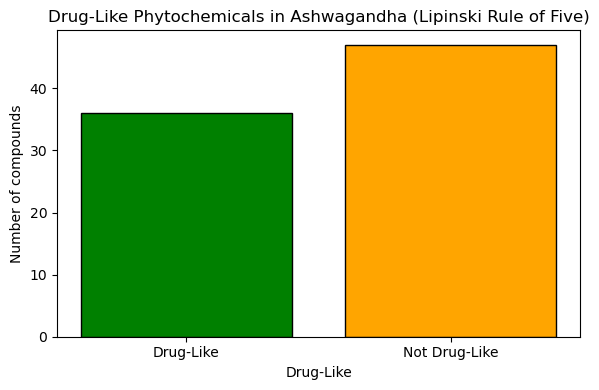

In [111]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
counts = [df_clean['Drug_Like'].sum(), (~df_clean['Drug_Like']).sum()]
plt.bar(['Drug-Like','Not Drug-Like'], counts,color=['green','orange'], edgecolor='black')
plt.title('Drug-Like Phytochemicals in Ashwagandha (Lipinski Rule of Five)')
plt.xlabel('Drug-Like')
plt.ylabel('Number of compounds')
plt.xticks([0,1], ['Drug-Like', 'Not Drug-Like'], rotation=0)
plt.tight_layout()
plt.savefig('drug_like_bar_chart_phase2.png',dpi=300)
plt.show()                                          

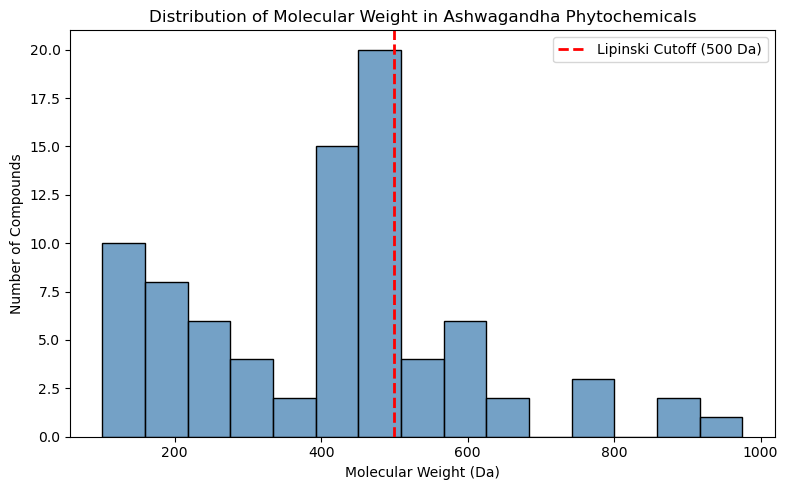

In [117]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Molecular_Weight'],bins=15, color='steelblue', edgecolor='black')
plt.axvline(x=500, color='red', linestyle='--', linewidth=2, label='Lipinski Cutoff (500 Da)')
plt.title('Distribution of Molecular Weight in Ashwagandha Phytochemicals')
plt.xlabel('Molecular Weight (Da)')
plt.ylabel('Number of Compounds')
plt.legend()
plt.tight_layout()
plt.savefig('mw_distribution_phase2.png', dpi=300)
plt.show()

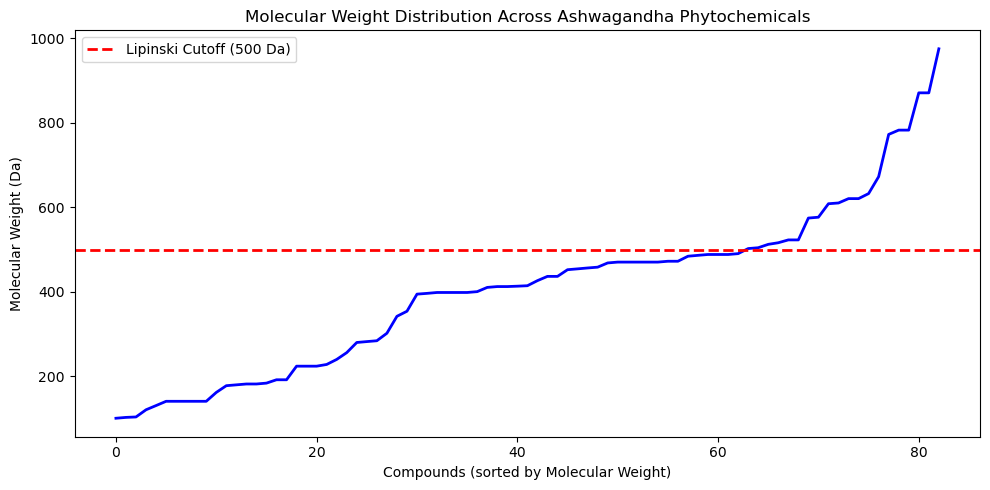

In [121]:
plt.figure(figsize=(10,5))
sorted_df=df_clean.sort_values('Molecular_Weight').reset_index(drop=True)
plt.plot (sorted_df.index, sorted_df['Molecular_Weight'],color='blue',linewidth=2)
plt.axhline(y=500, color='red', linestyle='--', linewidth=2, label='Lipinski Cutoff (500 Da)')
plt.title('Molecular Weight Distribution Across Ashwagandha Phytochemicals')
plt.xlabel('Compounds (sorted by Molecular Weight)')
plt.ylabel('Molecular Weight (Da)')
plt.legend()
plt.tight_layout()
plt.savefig('mw_distribution_pase2.png',dpi=300)
plt.show()                               

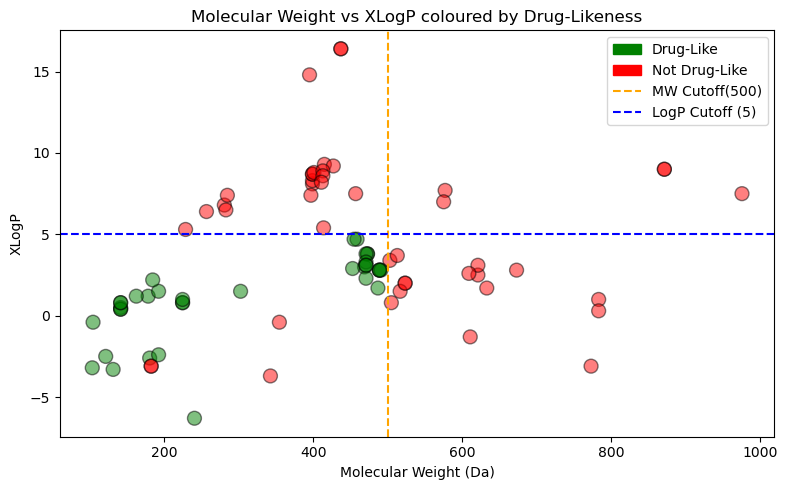

In [127]:
import matplotlib.patches as mpatches

plt.figure(figsize=(8,5))
colors= df_clean['Drug_Like'].map({True:'green', False:'red'})
plt.scatter(df_clean['Molecular_Weight'], df_clean['XLogP'], c= colors, edgecolor='black', s=100, alpha=0.5)
plt.axvline(x=500, color='orange', linestyle='--', linewidth=1.5)
plt.axhline(y=5, color='blue', linestyle='--', linewidth=1.5)
plt.title('Molecular Weight vs XLogP coloured by Drug-Likeness')
plt.xlabel('Molecular Weight (Da)')
plt.ylabel('XLogP')
drug_like_patch = mpatches.Patch(color='green', label='Drug-Like')
not_drug_like_patch= mpatches.Patch(color='red', label= 'Not Drug-Like')
mw_line = plt.Line2D([0],[0], color='orange', linestyle='--', label='MW Cutoff(500)')
logp_line=plt.Line2D([0],[0], color='blue', linestyle='--', label='LogP Cutoff (5)')
plt.legend(handles=[drug_like_patch, not_drug_like_patch, mw_line, logp_line])
plt.tight_layout()
plt.savefig('mw_vslogp_phase2.png', dpi=300)
plt.show()

In [ ]:
df_clean.to_csv("phase2_full_results.csv",index=False)
drug_like_phase2.to_csv("drug_like_phytochemicals_phase2.csv",index=False)
print("Phase 2 complete! All results s